In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3 #Varausenergia (GHz)
E_J = 8 #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[ 0.          4.0566369   7.73020385 11.07420845 13.12309129 17.41456479
 17.57786409 25.51228464 25.51356975 36.14800094 36.14800387]


## Simulaatio

In [4]:
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7 #Hilbert-avaruuden dimensio

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [5]:
def sim_pulse_2f(f_1,f_2,A,evolution,dim,f_rabi,K=20,t_ramp=5):
    T_floquet = 10*np.pi/(2*f_1-f_2) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on 50 aikapistettä

    N_edge=int(2*t_ramp/dt) #Määritellään reunojen pituudeksi 10 ns (5ns ramppi + 5ns, jotta amplitudi menee lähemmäs nollaa)
    N_pulse=int(1/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse = pulses.Pulse(f_1,f_ef,[pulses.gaussian(2*t_ramp,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,N_pulse,N_edge],time_unit=dt,second_frequency=f_2,drag=True)
    U_floquet=evolution.U_floquet(A*pulse.raw[N_edge:N_edge+K],dt)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge): #Aikakehitys rampille
        psi_eig_accum = evolution_eigenbasis.U(A*pulse.raw[i], dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä, jaetaan kahdellakymmenellä koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (20dt)
    N_sim=int(N_pulse/K)+1

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse = pulses.Pulse(f_1,f_ef,[pulses.gaussian(t_ramp*2,t_ramp/2),pulses.one,pulses.gaussian_opp(0,t_ramp/2)],[N_edge,K*k,N_edge],time_unit=dt,second_frequency=f_2,drag=True)
        for i in range(0, N_edge): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*pulse.raw[N_edge+K*k+i], dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla

    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    T_pulse = np.argmax(e_vals)*K*dt

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_sim)*K*dt
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(q,A,evolution,f_rabi,c_guess,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    c_vals=[]
    
    for i in range(min_range, max_range):
        f_1_shifted=f_1*(c_guess+i/scale)
        f_2_shifted=f_2*(c_guess+i/scale)

        c_vals.append(c_guess+i/scale)
        
        delta=q.frequency-2*f_1_shifted+f_2_shifted #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = sim_pulse_2f(f_1_shifted,f_2_shifted,A,evolution,dim,f_rabi,K=400)
        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=f_q-2f_1+f_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    c=c_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(c,pi_pulse,[e_max,f_max],max_e_vals)

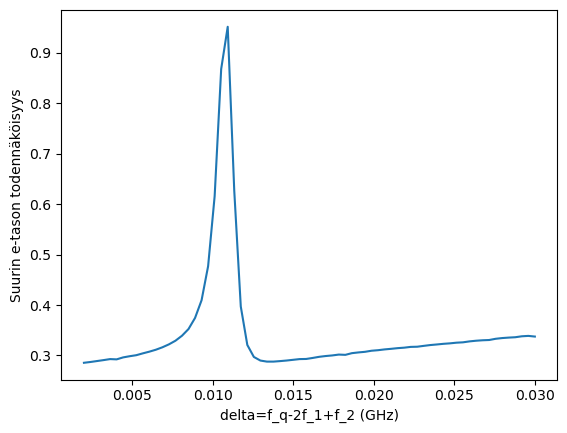

Amplitudi (GHz): 0.2028318451819653
AC-stark siirtymä (GHz): 0.9973074327668577
E-tason suurin todennäköisyys: 0.9519614276983315
Pulssin pituus (ns): 5148.351710709191
Rabi-taajuus (fourier):  9.641122183322991e-05


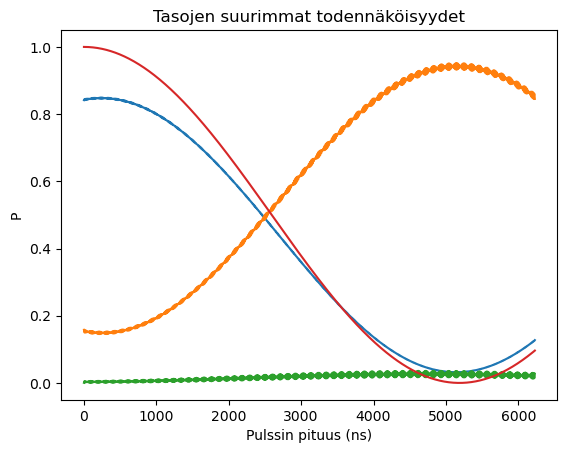

---------------------------------------------


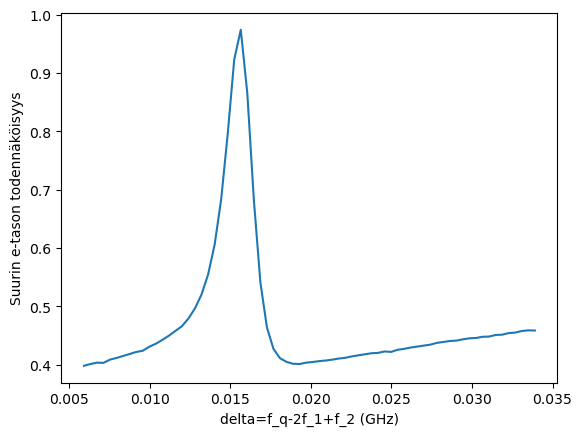

Amplitudi (GHz): 0.24339821421835836
AC-stark siirtymä (GHz): 0.9961428311268886
E-tason suurin todennäköisyys: 0.9741574173659392
Pulssin pituus (ns): 3047.531397718591
Rabi-taajuus (fourier):  0.0001702236048513135


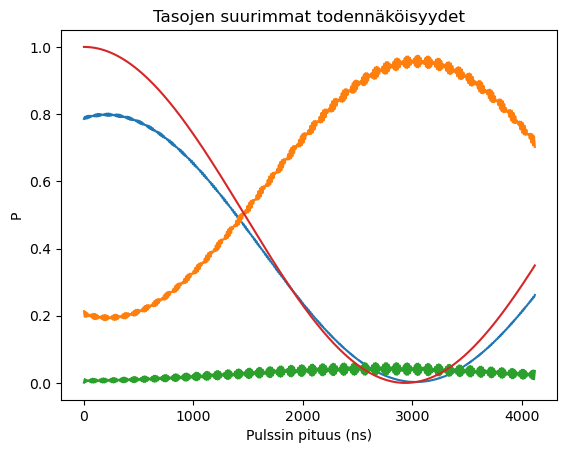

---------------------------------------------


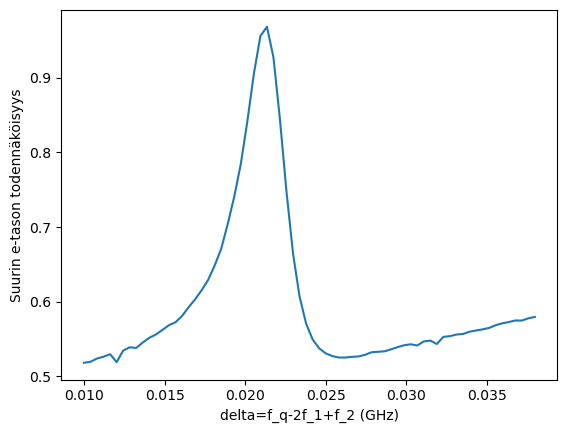

Amplitudi (GHz): 0.28396458325475143
AC-stark siirtymä (GHz): 0.9947362000891394
E-tason suurin todennäköisyys: 0.9691978926807687
Pulssin pituus (ns): 1884.0445964884884
Rabi-taajuus (fourier):  0.0002758382122480945


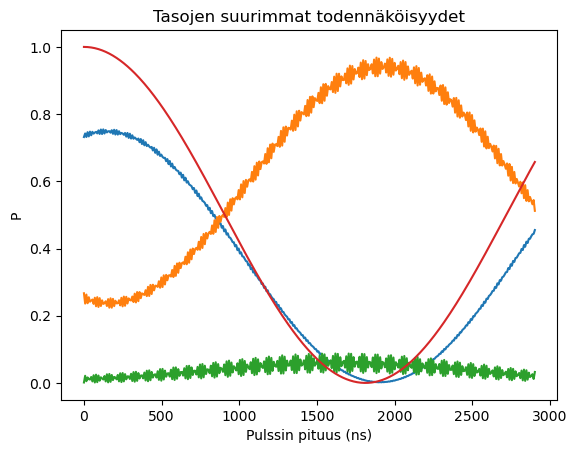

---------------------------------------------


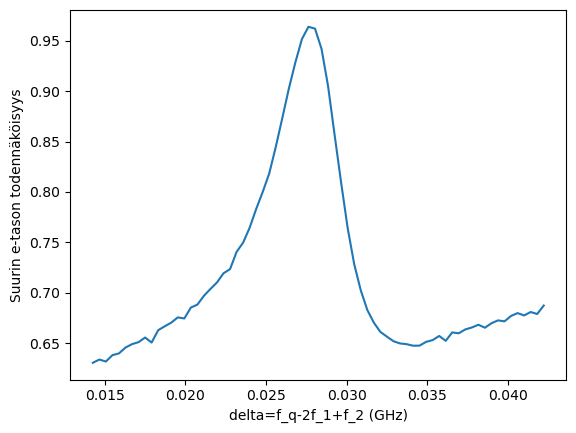

Amplitudi (GHz): 0.3245309522911445
AC-stark siirtymä (GHz): 0.9931875396536101
E-tason suurin todennäköisyys: 0.9644041196455072
Pulssin pituus (ns): 1317.7686695254288
Rabi-taajuus (fourier):  0.0004310611528107393


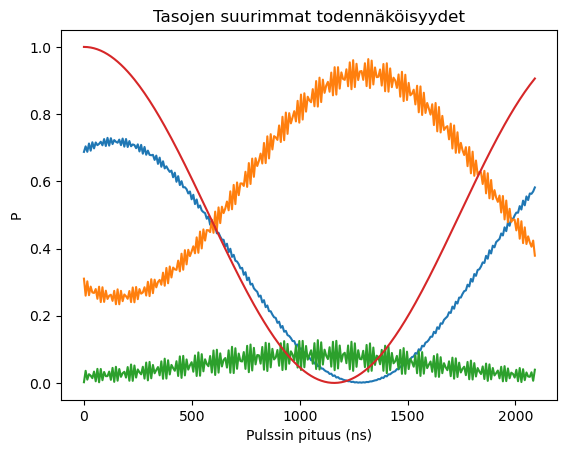

---------------------------------------------


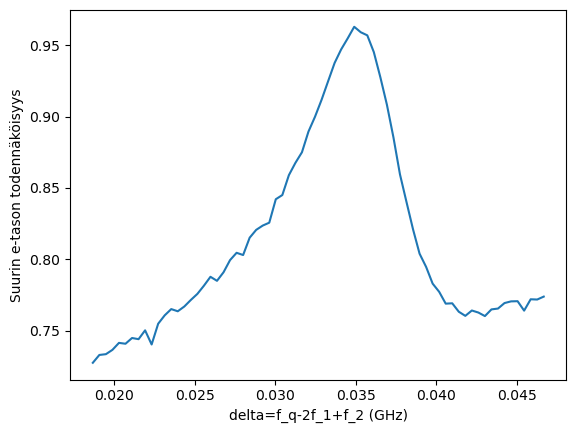

Amplitudi (GHz): 0.3650973213275375
AC-stark siirtymä (GHz): 0.9913968498203004
E-tason suurin todennäköisyys: 0.9628417710911374
Pulssin pituus (ns): 913.9492119009988
Rabi-taajuus (fourier):  0.0006591463150007107


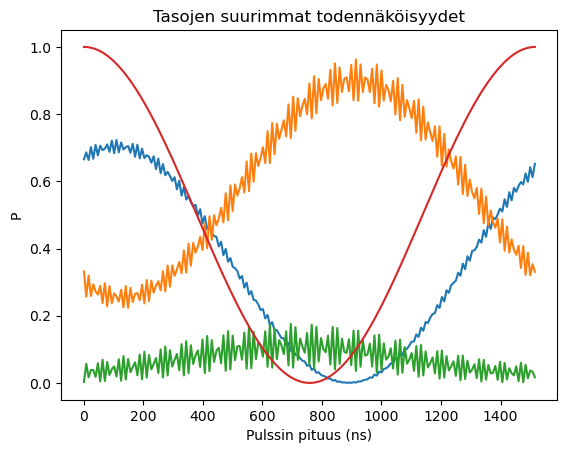

---------------------------------------------


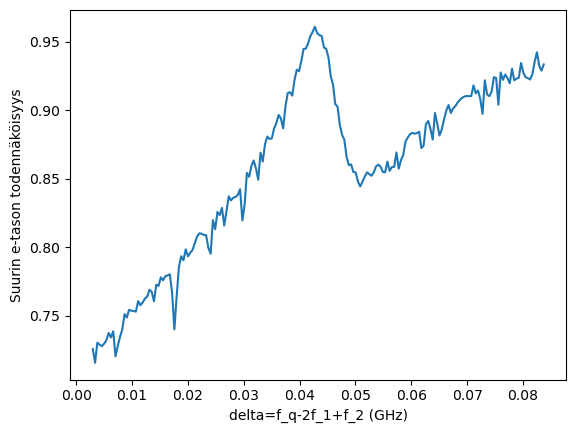

Amplitudi (GHz): 0.4056636903639306
AC-stark siirtymä (GHz): 0.9894641305892106
E-tason suurin todennäköisyys: 0.9610900738019532
Pulssin pituus (ns): 641.796778543586
Rabi-taajuus (fourier):  0.0008992114422607191


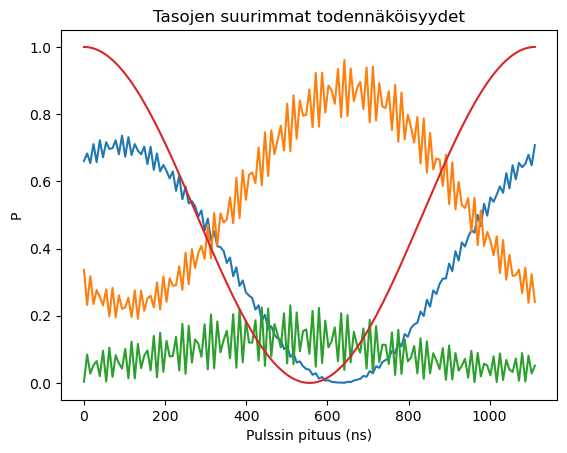

---------------------------------------------


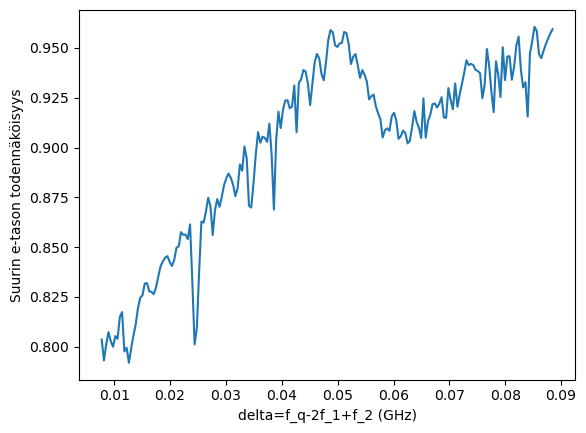

Amplitudi (GHz): 0.4462300594003236
AC-stark siirtymä (GHz): 0.9789893819603406
E-tason suurin todennäköisyys: 0.9606283037259541
Pulssin pituus (ns): 300.6002591404748
Rabi-taajuus (fourier):  0.004402048742339975


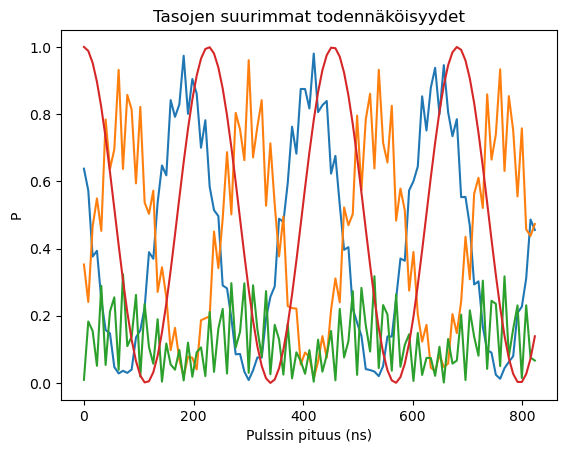

---------------------------------------------


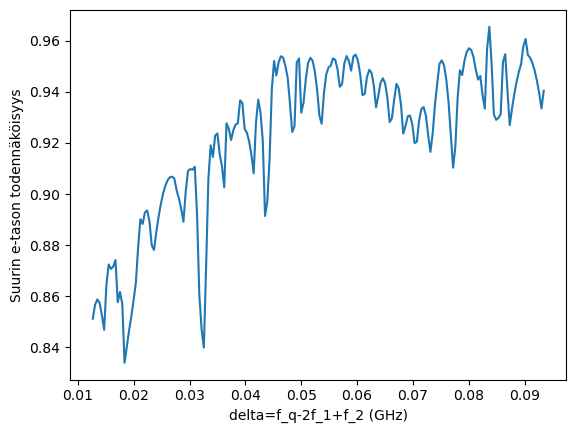

Amplitudi (GHz): 0.4867964284367167
AC-stark siirtymä (GHz): 0.9793726039336904
E-tason suurin todennäköisyys: 0.9654909454217541
Pulssin pituus (ns): 490.26114337530333
Rabi-taajuus (fourier):  0.002923624825101266


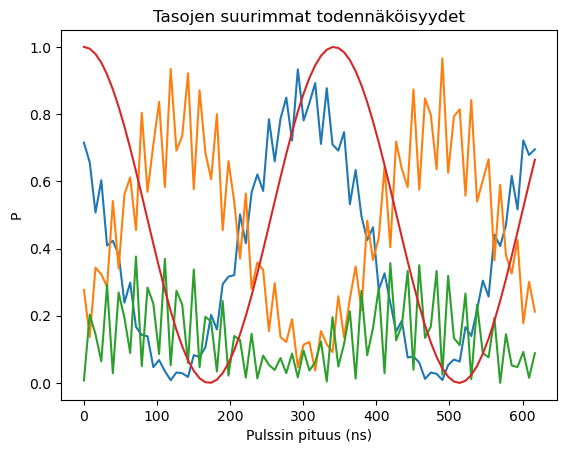

---------------------------------------------


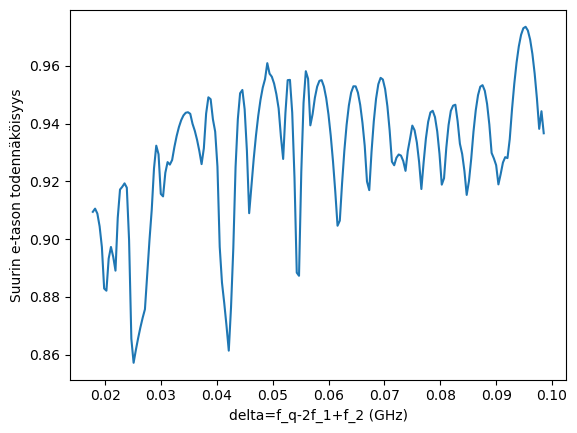

Amplitudi (GHz): 0.5273627974731098
AC-stark siirtymä (GHz): 0.9765137965092601
E-tason suurin todennäköisyys: 0.9735317674049689
Pulssin pituus (ns): 142.75057199370934
Rabi-taajuus (fourier):  0.0029831265404636127


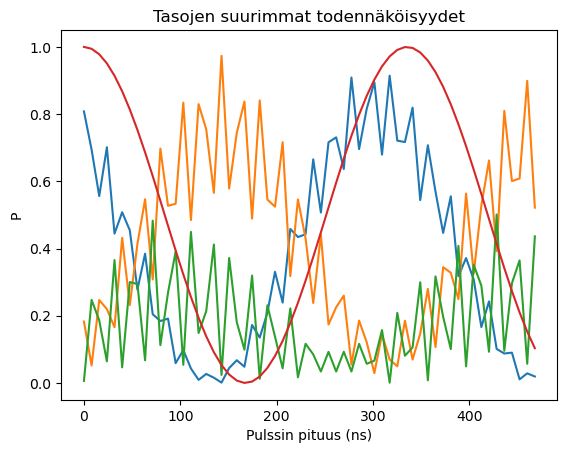

---------------------------------------------


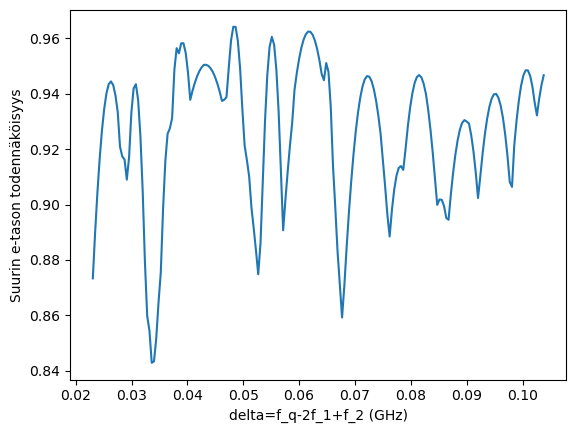

Amplitudi (GHz): 0.5679291665095029
AC-stark siirtymä (GHz): 0.9881129596870495
E-tason suurin todennäköisyys: 0.9642064586458077
Pulssin pituus (ns): 258.63725364819715
Rabi-taajuus (fourier):  0.006239318385501477


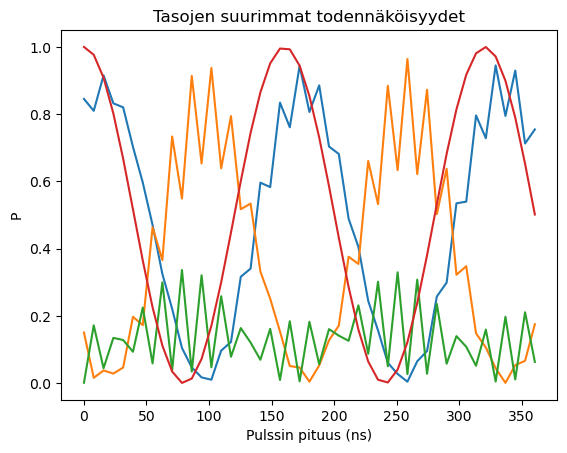

---------------------------------------------


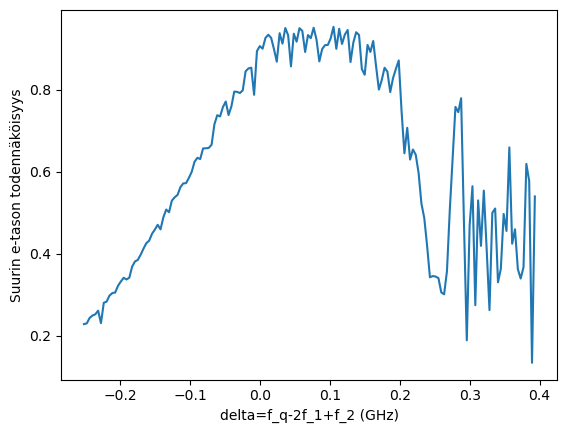

Amplitudi (GHz): 0.608495535545896
AC-stark siirtymä (GHz): 0.9740700934670588
E-tason suurin todennäköisyys: 0.9529338897977515
Pulssin pituus (ns): 159.00966464365038
Rabi-taajuus (fourier):  0.0031494332465521768


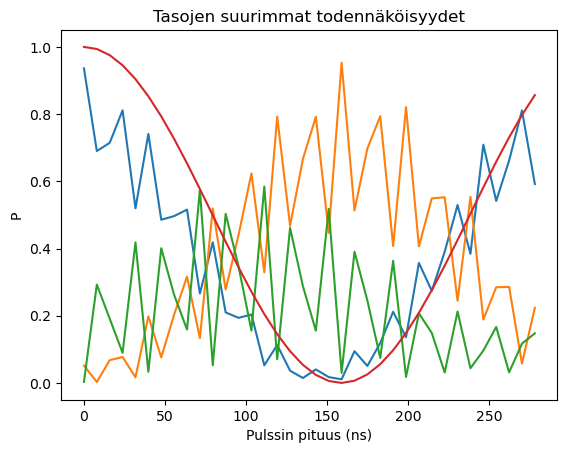

---------------------------------------------


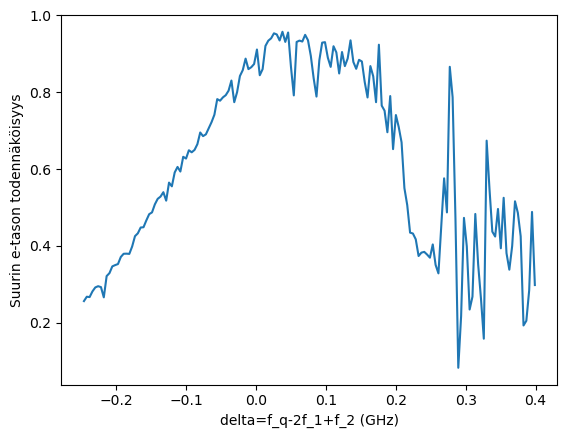

Amplitudi (GHz): 0.649061904582289
AC-stark siirtymä (GHz): 0.9906851978492878
E-tason suurin todennäköisyys: 0.9646315982948147
Pulssin pituus (ns): 226.69714950308062
Rabi-taajuus (fourier):  0.011190986136082067


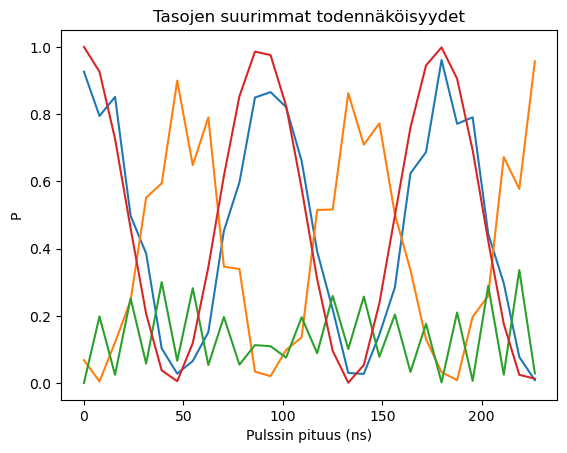

---------------------------------------------


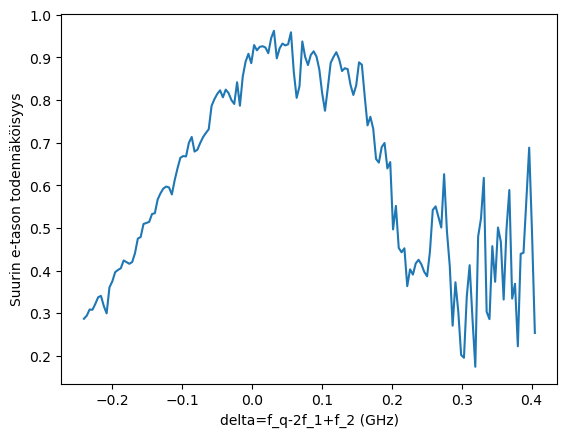

Amplitudi (GHz): 0.689628273618682
AC-stark siirtymä (GHz): 0.9922582728337367
E-tason suurin todennäköisyys: 0.9623635413550002
Pulssin pituus (ns): 109.2665026833103
Rabi-taajuus (fourier):  0.01434741812318214


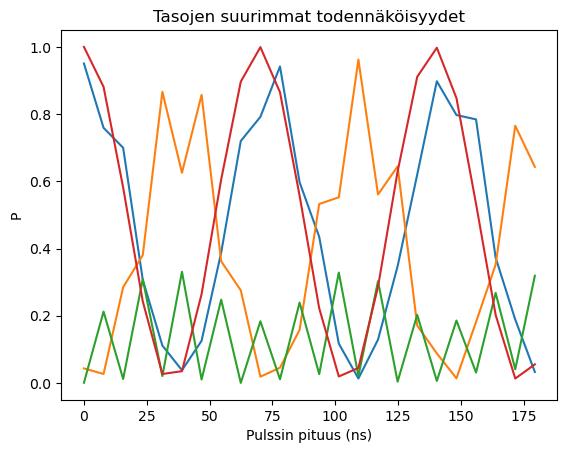

---------------------------------------------


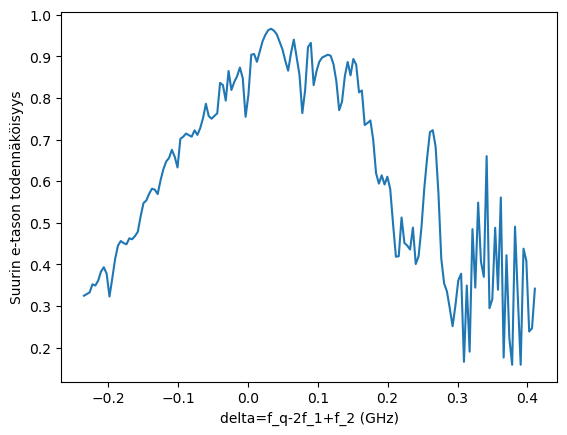

Amplitudi (GHz): 0.730194642655075
AC-stark siirtymä (GHz): 0.9917893184204053
E-tason suurin todennäköisyys: 0.9661366095506508
Pulssin pituus (ns): 31.233762256744125
Rabi-taajuus (fourier):  0.016221955164401915


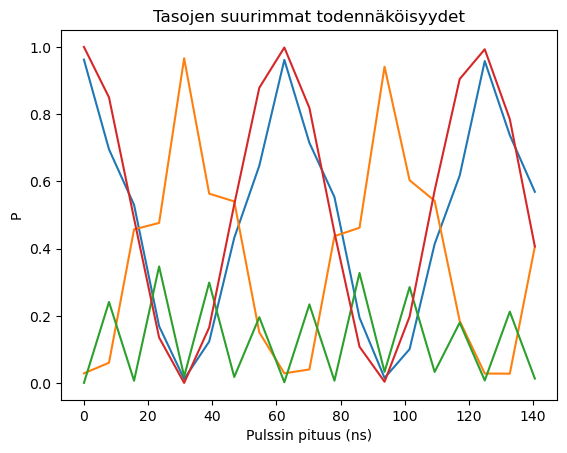

---------------------------------------------


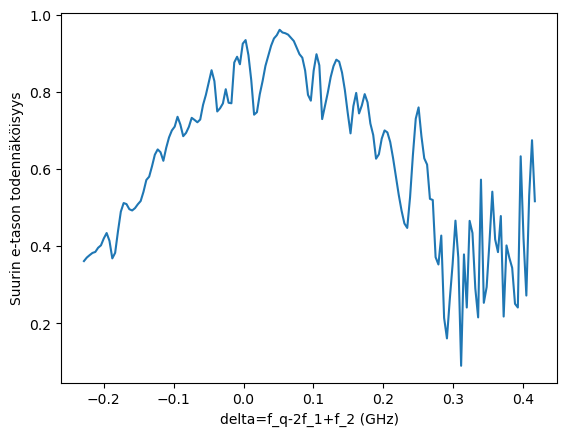

Amplitudi (GHz): 0.770761011691468
AC-stark siirtymä (GHz): 0.9872783346092938
E-tason suurin todennäköisyys: 0.9615939133907169
Pulssin pituus (ns): 94.12941830404965
Rabi-taajuus (fourier):  0.015843774614556962


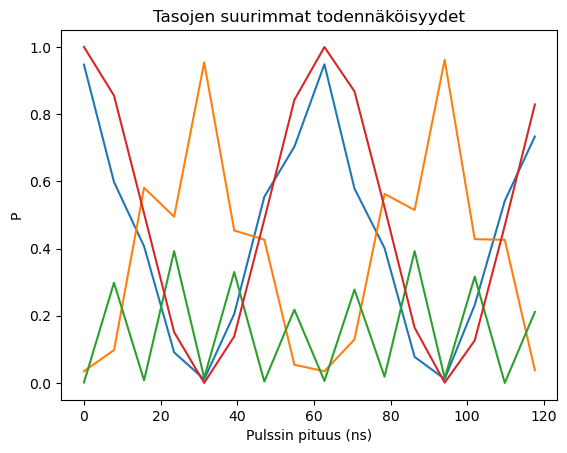

---------------------------------------------


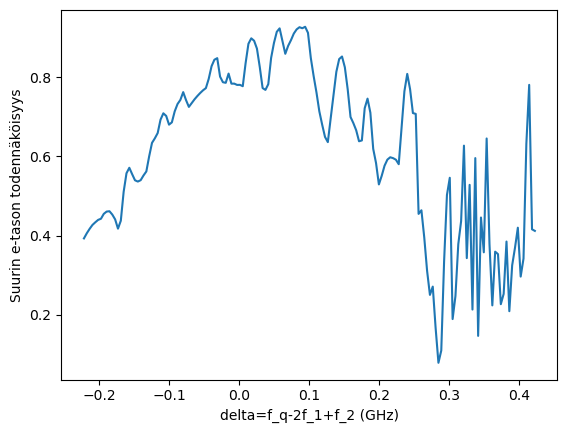

Amplitudi (GHz): 0.8113273807278611
AC-stark siirtymä (GHz): 0.9767253214004021
E-tason suurin todennäköisyys: 0.9423821549676173
Pulssin pituus (ns): 103.07530795013805
Rabi-taajuus (fourier):  0.01434741812318214


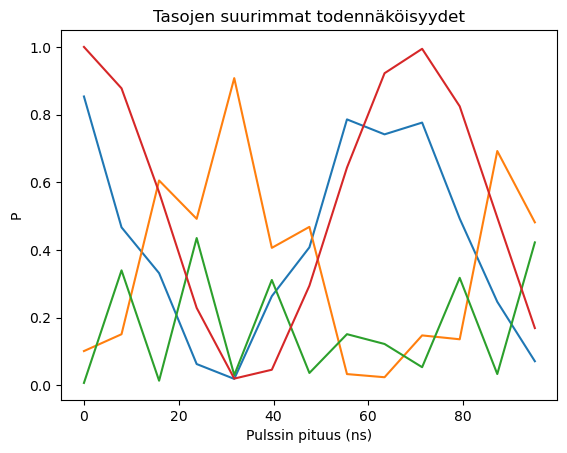

---------------------------------------------


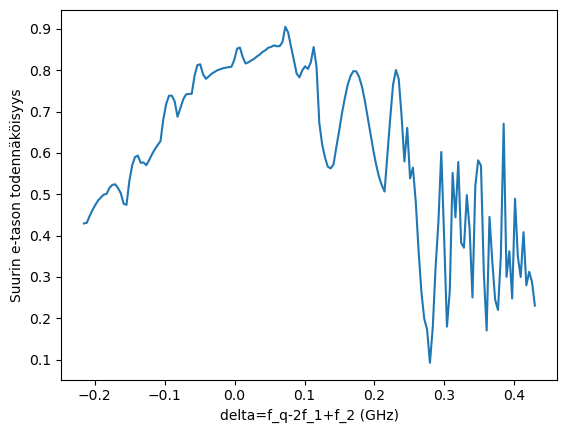

Amplitudi (GHz): 0.8518937497642542
AC-stark siirtymä (GHz): 0.9821302787937302
E-tason suurin todennäköisyys: 0.9254004376084558
Pulssin pituus (ns): 78.85234894287169
Rabi-taajuus (fourier):  0.01908830411171189


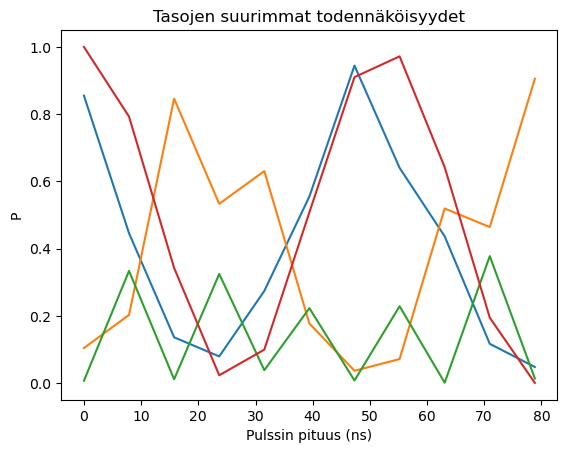

---------------------------------------------


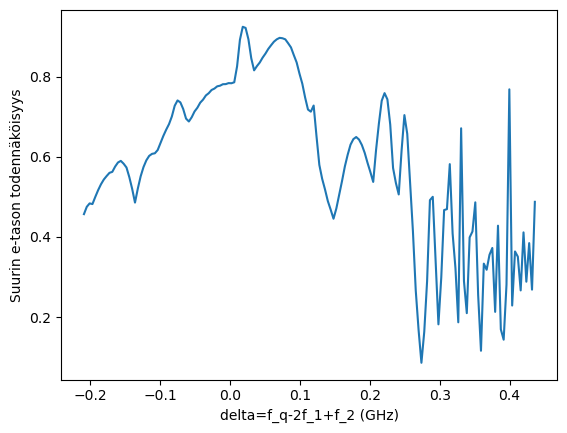

Amplitudi (GHz): 0.8924601188006474
AC-stark siirtymä (GHz): 0.9954932067892781
E-tason suurin todennäköisyys: 0.9251685285111367
Pulssin pituus (ns): 54.455716267923435
Rabi-taajuus (fourier):  0.026086214769422068


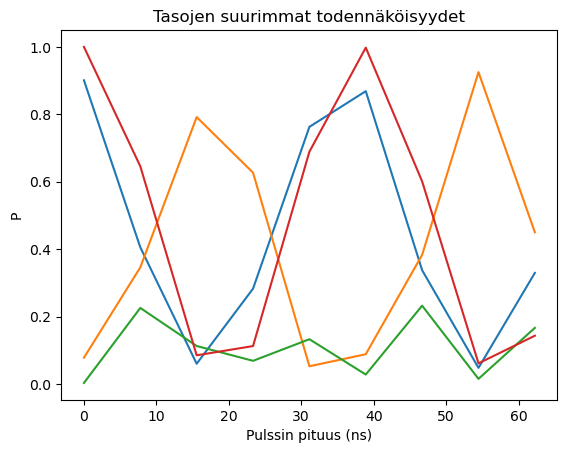

---------------------------------------------


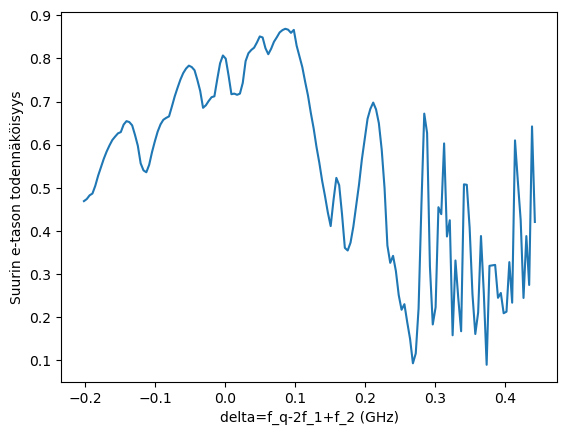

Amplitudi (GHz): 0.9330264878370402
AC-stark siirtymä (GHz): 0.9788141053870458
E-tason suurin todennäköisyys: 0.8687305032304028
Pulssin pituus (ns): 15.823899354245658
Rabi-taajuus (fourier):  0.023336162007585405


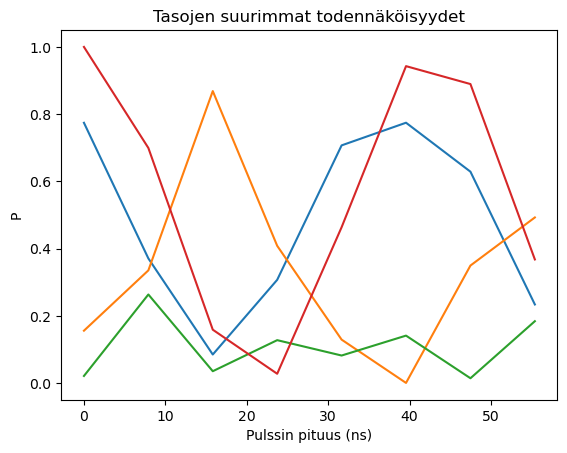

---------------------------------------------


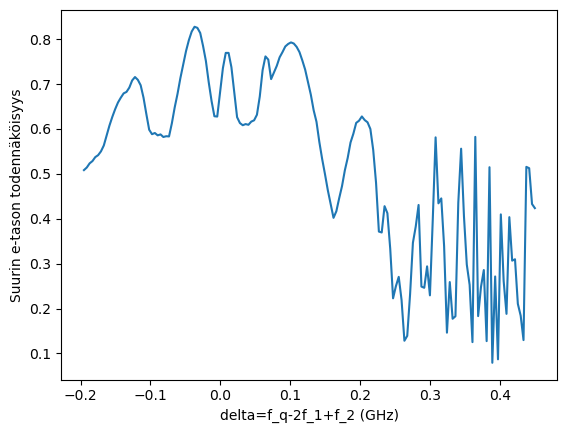

Amplitudi (GHz): 0.9735928568734333
AC-stark siirtymä (GHz): 1.0090929745870334
E-tason suurin todennäköisyys: 0.8274308238610092
Pulssin pituus (ns): 38.372717579614694
Rabi-taajuus (fourier):  0.03664408142272195


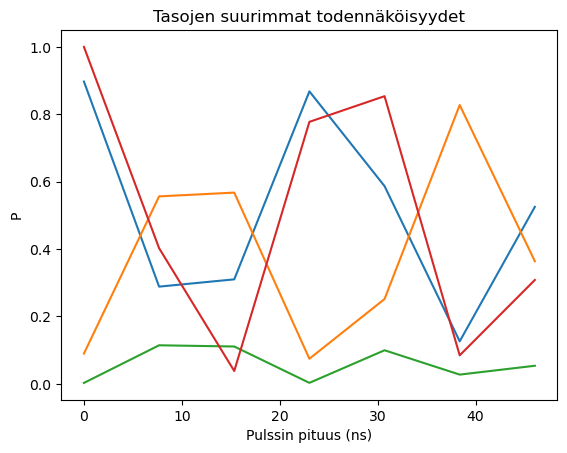

---------------------------------------------


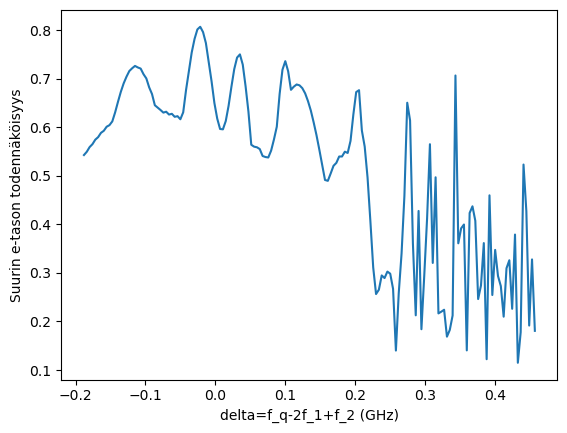

Amplitudi (GHz): 1.0141592259098264
AC-stark siirtymä (GHz): 1.0053298143892406
E-tason suurin todennäköisyys: 0.8067629492976677
Pulssin pituus (ns): 38.5163547038797
Rabi-taajuus (fourier):  0.038334507797877275


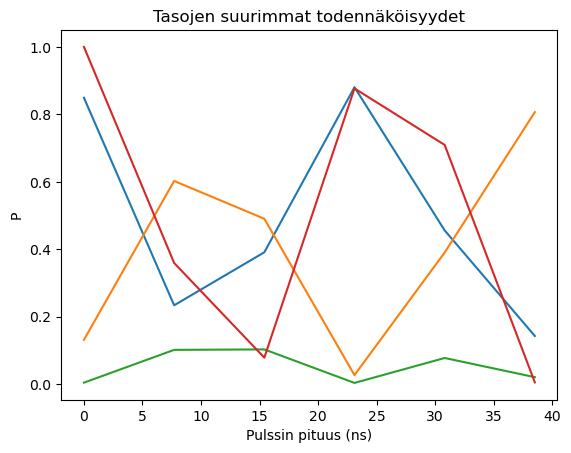

---------------------------------------------


In [6]:
c_vals = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals= []

min_range = 0.05
max_range = 0.25
N_data=21
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)
    f_rabi= 0.03295*A**3 - 0.01835*A**2 + 0.005275*A - 0.0004297 #Arvaus Rabi-taajuudelle
    c=-0.01277*A**2 - 0.01808*A + 0.9988 #Arvaus c:n arvolle
    if i < 5:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,c,[-20,50],10000)
    elif i < 10:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,c,[-100,100],10000)
    else:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi,c,[-80,80],1000)
    c_vals.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])

    #Löydetyt optimaaliset ajotaajuudet
    f_1_opt = f_1*c_vals[-1]
    f_2_opt = f_2*c_vals[-1]

    m=10
    vals=sim_pulse_2f(f_1_opt,f_2_opt,A,evolution_eigenbasis,dim,f_rabi/m,K=400)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", c_vals[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    max_vals.append([vals[0],vals[1]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    T_floquet = 10*np.pi/(2*f_1-f_2) #Floquet-jakson pituus
    freqs = np.fft.rfftfreq(len(g_vals), d=T_floquet) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.2028318451819653), np.float64(0.24339821421835836), np.float64(0.28396458325475143), np.float64(0.3245309522911445), np.float64(0.3650973213275375), np.float64(0.4056636903639306), np.float64(0.4462300594003236), np.float64(0.4867964284367167), np.float64(0.5273627974731098), np.float64(0.5679291665095029), np.float64(0.608495535545896), np.float64(0.649061904582289), np.float64(0.689628273618682), np.float64(0.730194642655075), np.float64(0.770761011691468), np.float64(0.8113273807278611), np.float64(0.8518937497642542), np.float64(0.8924601188006474), np.float64(0.9330264878370402), np.float64(0.9735928568734333), np.float64(1.0141592259098264)]


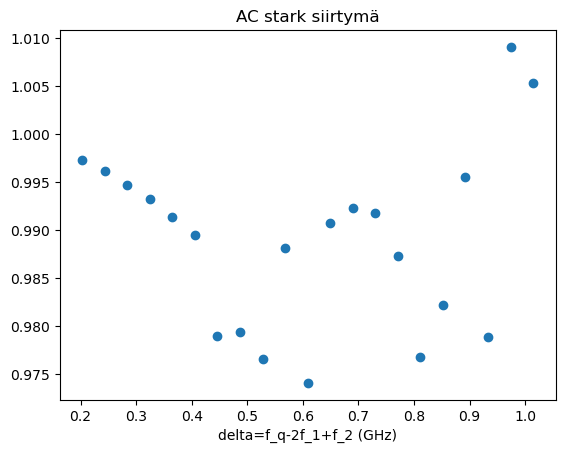

[np.float64(0.9973074327668577), np.float64(0.9961428311268886), np.float64(0.9947362000891394), np.float64(0.9931875396536101), np.float64(0.9913968498203004), np.float64(0.9894641305892106), np.float64(0.9789893819603406), np.float64(0.9793726039336904), np.float64(0.9765137965092601), np.float64(0.9881129596870495), np.float64(0.9740700934670588), np.float64(0.9906851978492878), np.float64(0.9922582728337367), np.float64(0.9917893184204053), np.float64(0.9872783346092938), np.float64(0.9767253214004021), np.float64(0.9821302787937302), np.float64(0.9954932067892781), np.float64(0.9788141053870458), np.float64(1.0090929745870334), np.float64(1.0053298143892406)]


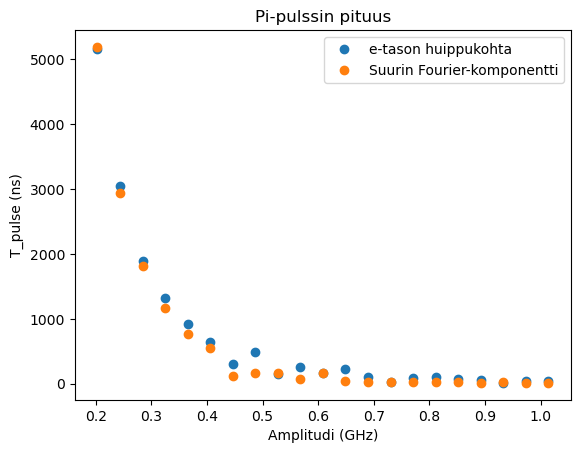

[np.float64(5148.351710709191), np.float64(3047.531397718591), np.float64(1884.0445964884884), np.float64(1317.7686695254288), np.float64(913.9492119009988), np.float64(641.796778543586), np.float64(300.6002591404748), np.float64(490.26114337530333), np.float64(142.75057199370934), np.float64(258.63725364819715), np.float64(159.00966464365038), np.float64(226.69714950308062), np.float64(109.2665026833103), np.float64(31.233762256744125), np.float64(94.12941830404965), np.float64(103.07530795013805), np.float64(78.85234894287169), np.float64(54.455716267923435), np.float64(15.823899354245658), np.float64(38.372717579614694), np.float64(38.5163547038797)]


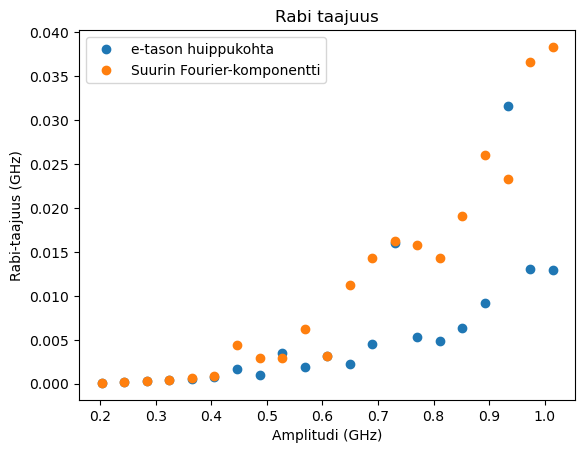

[np.float64(9.641122183322991e-05), np.float64(0.0001702236048513135), np.float64(0.0002758382122480945), np.float64(0.0004310611528107393), np.float64(0.0006591463150007107), np.float64(0.0008992114422607191), np.float64(0.004402048742339975), np.float64(0.002923624825101266), np.float64(0.0029831265404636127), np.float64(0.006239318385501477), np.float64(0.0031494332465521768), np.float64(0.011190986136082067), np.float64(0.01434741812318214), np.float64(0.016221955164401915), np.float64(0.015843774614556962), np.float64(0.01434741812318214), np.float64(0.01908830411171189), np.float64(0.026086214769422068), np.float64(0.023336162007585405), np.float64(0.03664408142272195), np.float64(0.038334507797877275)]


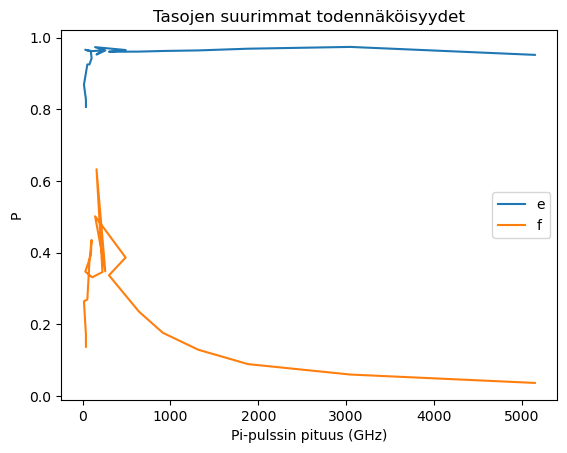

[np.float64(0.9519614276983315), np.float64(0.9741574173659392), np.float64(0.9691978926807687), np.float64(0.9644041196455072), np.float64(0.9628417710911374), np.float64(0.9610900738019532), np.float64(0.9606283037259541), np.float64(0.9654909454217541), np.float64(0.9735317674049689), np.float64(0.9642064586458077), np.float64(0.9529338897977515), np.float64(0.9646315982948147), np.float64(0.9623635413550002), np.float64(0.9661366095506508), np.float64(0.9615939133907169), np.float64(0.9423821549676173), np.float64(0.9254004376084558), np.float64(0.9251685285111367), np.float64(0.8687305032304028), np.float64(0.8274308238610092), np.float64(0.8067629492976677)]
[np.float64(0.03607775617627439), np.float64(0.05948352893066435), np.float64(0.08857083280426582), np.float64(0.128676219835584), np.float64(0.17601063904090397), np.float64(0.23520985212745615), np.float64(0.33655746144391624), np.float64(0.38613827956021685), np.float64(0.5013489093499132), np.float64(0.3476463658176144), 

'\nplt.figure(figsize=(6, 6))\nplt.imshow(data, aspect=\'auto\')  # stretches to square\nplt.colorbar(label="e-tason suurin todennäköisyys")\nplt.show() '

In [7]:
print(A_vals)

plt.figure()
plt.plot(A_vals, c_vals, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=f_q-2f_1+f_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.plot(A_vals, 1/(2*np.array(rabis)), 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, 1/(2*np.array(pulse_lengths)), 'o')
plt.plot(A_vals, rabis, 'o')
plt.legend(["e-tason huippukohta","Suurin Fourier-komponentti"])
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

"""
plt.figure(figsize=(6, 6))
plt.imshow(data, aspect='auto')  # stretches to square
plt.colorbar(label="e-tason suurin todennäköisyys")
plt.show() """